In [1]:
#Librairies importaion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
#Load the data
X_train = pd.read_csv('../data/X_train_processed.csv')
X_val = pd.read_csv('../data/X_val_processed.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_val = pd.read_csv('../data/y_val.csv').values.ravel()

In [4]:
#Model Retraining
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

In [5]:
log_reg.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [6]:
#ROC Curve
log_prob_vals = log_reg.predict_proba(X_val)[:, 1]
rf_prob_vals = rf_model.predict_proba(X_val)[:, 1]

In [7]:
log_fpr, log_tpr, _ = roc_curve(y_val, log_prob_vals)
rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_prob_vals)

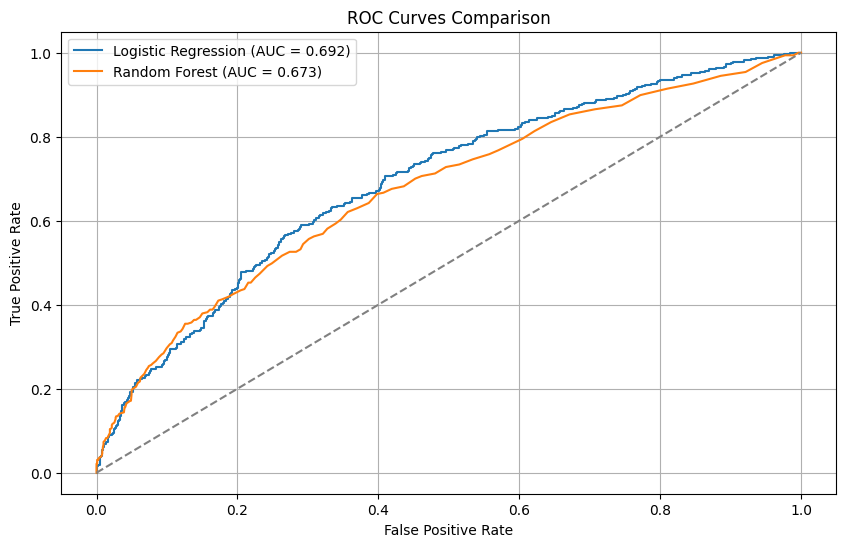

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(log_fpr, log_tpr, label='Logistic Regression (AUC = {:.3f})'.format(roc_auc_score(y_val, log_prob_vals)))
plt.plot(rf_fpr, rf_tpr, label='Random Forest (AUC = {:.3f})'.format(roc_auc_score(y_val, rf_prob_vals)))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
#Logistic Regression Coefficients
log_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Top positive coefficients:", log_coefficients.head(10))
print("Top negative coefficients:", log_coefficients.tail(10))

Top positive coefficients:                  Feature  Coefficient
8457      Geo_Code_95018     1.696298
4418   Customer Id_H2733     1.631764
6223   Customer Id_H5840     1.550349
7054   Customer Id_H7281     1.520472
2020  Customer Id_H16242     1.496050
6435   Customer Id_H6225     1.490166
7944      Geo_Code_69069     1.489923
846   Customer Id_H14233     1.481393
4655   Customer Id_H3227     1.433751
6142   Customer Id_H5669     1.429812
Top negative coefficients:              Feature  Coefficient
8404  Geo_Code_93045    -0.894595
8042  Geo_Code_74042    -0.929292
7261  Geo_Code_13214    -0.948411
8067  Geo_Code_74173    -0.951734
8360  Geo_Code_92009    -0.973329
7666  Geo_Code_51454    -0.975279
8111  Geo_Code_75113    -0.998638
7304  Geo_Code_19031    -1.019772
7752   Geo_Code_6004    -1.046563
8034  Geo_Code_74010    -1.233786


In [10]:
#Random Forest Feature Importances
rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top Feature Importances:", rf_importances.head(15))

Top Feature Importances:                  Feature  Importance
3     Building Dimension    0.121278
5      Date_of_Occupancy    0.040639
0      YearOfObservation    0.033185
1         Insured_Period    0.030497
4          Building_Type    0.021279
2            Residential    0.009137
7165  Building_Painted_V    0.006597
7171   NumberOfWindows_2    0.006206
7172   NumberOfWindows_3    0.005136
7176   NumberOfWindows_7    0.004473
7174   NumberOfWindows_5    0.004450
7173   NumberOfWindows_4    0.004331
7175   NumberOfWindows_6    0.003626
7789       Geo_Code_6088    0.003190
7177   NumberOfWindows_8    0.003072


In [11]:
#Save for Report
log_coefficients.to_csv('../data/logistic_regression_coefficients.csv', index=False)
rf_importances.to_csv('../data/random_forest_feature_importances.csv', index=False)